# [Super AI Engineer Season 6] Hackathon Week 6
## 5 Domains Hackathon: Chest Disease Prediction — DenseNet121 Fine-tuning

**Super AI Engineer Season 6 - Level 2 Hackathon**

- Dataset: Chest Disease Detection
- Domain: Computer Vision / Medical Image Classification
- Task: Multi-label classification ของ 13 โรคจากภาพ Chest X-ray
- Metric: Mean Column-wise ROC AUC
- Approach: **DenseNet121 fine-tuning end-to-end** (CheXNet architecture)

### แนวทาง
ใช้ DenseNet121 pretrained บน ImageNet แล้ว fine-tune ทั้งโมเดลบน dataset นี้โดยตรง
แทนการใช้ frozen features + CatBoost ซึ่ง DenseNet121 เป็น architecture เดียวกับที่ Stanford CheXNet ใช้และได้ผลดีที่สุดสำหรับ Chest X-ray classification

# 1. Setup & Imports
### 1.1 ติดตั้ง library และกำหนด config ทั้งหมด

รวม path, hyperparameter, seed ไว้ที่ cell นี้ที่เดียว เพื่อให้แก้ง่ายก่อนรัน

In [1]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ─── SEED ───────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ─── CONFIG ─────────────────────────────────────────────────────────────────
KAGGLE_MODE = Path('/kaggle/input').exists()
WORK_DIR    = Path('/kaggle/working') if KAGGLE_MODE else Path('.')
WORK_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR_CANDIDATES = [
    Path('/kaggle/input/competitions/chest-disease-detection'),
    Path('/kaggle/input/individual-test-chest-disease-detection'),
    Path('/content'),
    Path('.'),
]
data_dir = next((p for p in DATA_DIR_CANDIDATES if p.exists()), Path('.'))

# Training hyperparameters
IMG_SIZE    = 224          # DenseNet121 native size
BATCH_SIZE  = 32           # ลดเป็น 16 ถ้า OOM
NUM_EPOCHS  = 5            # 5 epochs น่าจะพอ ถ้าเวลาน้อยลดเป็น 3
LR_HEAD     = 1e-3         # LR สำหรับ classifier head
LR_BACKBONE = 1e-4         # LR สำหรับ backbone (fine-tune ช้ากว่า)
NUM_WORKERS = 2
USE_TTA     = True         # Test Time Augmentation
TTA_N       = 5            # จำนวน TTA passes

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

LABEL_COLUMNS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity',
    'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax'
]
NUM_CLASSES = len(LABEL_COLUMNS)

submission_path = WORK_DIR / '5hack_chest_disease_v2_submission.csv'
model_path      = WORK_DIR / 'densenet121_chest_best.pth'

print(f'Device : {DEVICE}')
print(f'Kaggle : {KAGGLE_MODE}')
print(f'Data   : {data_dir.resolve()}')
print(f'Output : {WORK_DIR.resolve()}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
Kaggle : True
Data   : /kaggle/input/competitions/chest-disease-detection
Output : /kaggle/working
GPU    : Tesla T4


# 2. Data Loading & Inspection
### 2.1 โหลด train.csv และ sample_submission

ตรวจ shape, missing values, และ class distribution ก่อน

In [2]:
def find_file(root: Path, names):
    for name in names:
        p = root / name
        if p.exists():
            return p
    for name in names:
        hits = list(root.rglob(name))
        if hits:
            return hits[0]
    raise FileNotFoundError(f'Cannot find {names} under {root}')

def find_image_dir(root: Path):
    """หา directory ที่มี .jpg files"""
    for subdir in ['train_images', 'images', 'train', '']:
        d = root / subdir if subdir else root
        if d.is_dir():
            jpegs = list(d.glob('*.jpg'))
            if jpegs:
                return d
    # recursive search
    for d in root.rglob('*'):
        if d.is_dir() and list(d.glob('*.jpg')):
            return d
    return root

train_path      = find_file(data_dir, ['train.csv'])
sample_sub_path = find_file(data_dir, ['sample_submission.csv', 'test_submission.csv'])

train_df  = pd.read_csv(train_path)
sample_df = pd.read_csv(sample_sub_path)

# normalize column name
for df in [train_df, sample_df]:
    for col in ['filename', 'image_name', 'id', 'image_id', 'Image']:
        if col in df.columns:
            df.rename(columns={col: 'image_name'}, inplace=True)
            break

print('Train shape  :', train_df.shape)
print('Sample shape :', sample_df.shape)

# ตรวจ image directory
train_img_dir = find_image_dir(data_dir / 'train_images' if (data_dir / 'train_images').exists() else data_dir)
test_img_dir  = find_image_dir(data_dir / 'test_images'  if (data_dir / 'test_images').exists()  else data_dir)
print('Train img dir:', train_img_dir)
print('Test  img dir:', test_img_dir)
print('Train imgs   :', len(list(train_img_dir.glob('*.jpg'))))
print('Test  imgs   :', len(list(test_img_dir.glob('*.jpg'))))

# กรองเฉพาะ sample ที่มี label
train_labeled = train_df.dropna(subset=LABEL_COLUMNS).copy()
test_df = sample_df[['image_name']].copy()

print(f'\nLabeled train rows : {len(train_labeled)}')
print(f'Test rows          : {len(test_df)}')
display(train_labeled[['image_name'] + LABEL_COLUMNS].head())

Train shape  : (9963, 14)
Sample shape : (2506, 14)
Train img dir: /kaggle/input/competitions/chest-disease-detection/images/images
Test  img dir: /kaggle/input/competitions/chest-disease-detection/images/images
Train imgs   : 12469
Test  imgs   : 12469

Labeled train rows : 9963
Test rows          : 2506


,image_name,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax
0,cxr00004.jpg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,cxr00005.jpg,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,cxr00006.jpg,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,cxr00009.jpg,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,cxr00012.jpg,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


Positive rates per class:
  Atelectasis                        : 0.173
  Cardiomegaly                       : 0.147
  Consolidation                      : 0.046
  Edema                              : 0.091
  Enlarged Cardiomediastinum         : 0.051
  Fracture                           : 0.050
  Lung Lesion                        : 0.091
  Lung Opacity                       : 0.190
  No Finding                         : 0.321
  Pleural Effusion                   : 0.213
  Pleural Other                      : 0.035
  Pneumonia                          : 0.129
  Pneumothorax                       : 0.082


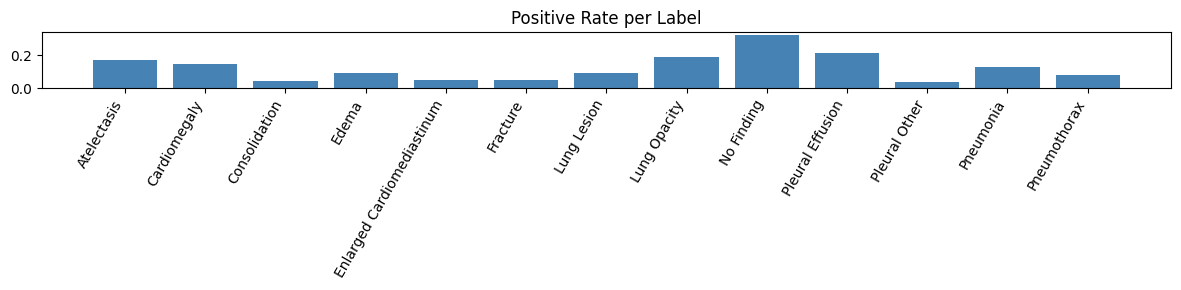


pos_weight (for BCEWithLogitsLoss): [ 4.79  5.81 20.94 10.05 18.73 19.13 10.01  4.27  2.11  3.69 27.3   6.77
 11.18]


In [3]:
# Class distribution and pos_weight for BCEWithLogitsLoss
pos_counts = train_labeled[LABEL_COLUMNS].sum()
neg_counts = len(train_labeled) - pos_counts
pos_weight = (neg_counts / pos_counts).values

print('Positive rates per class:')
for lbl, rate in zip(LABEL_COLUMNS, pos_counts / len(train_labeled)):
    print(f'  {lbl:<35}: {rate:.3f}')

plt.figure(figsize=(12, 3))
plt.bar(LABEL_COLUMNS, pos_counts / len(train_labeled), color='steelblue')
plt.xticks(rotation=60, ha='right')
plt.title('Positive Rate per Label')
plt.tight_layout()
plt.show()

print('\npos_weight (for BCEWithLogitsLoss):', np.round(pos_weight, 2))

# 3. Dataset & Augmentation
### 3.1 สร้าง PyTorch Dataset

- Train: augmentation เบาๆ (horizontal flip, slight rotation, color jitter)
- Val/Test: center crop เท่านั้น
- TTA: หลาย augmentation pass ตอน inference

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

tta_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class ChestDataset(Dataset):
    def __init__(self, df, img_dir, label_cols, transform=None, is_test=False):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = Path(img_dir)
        self.label_cols= label_cols
        self.transform = transform
        self.is_test   = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = self.img_dir / row['image_name']
        img      = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        if self.is_test:
            return img, row['image_name']
        labels = torch.FloatTensor(row[self.label_cols].values.astype(float))
        return img, labels


print('Dataset classes defined.')

Dataset classes defined.


# 4. Train/Validation Split
### 4.1 แบ่ง 90/10 stratified บน label sum

ใช้ label count เป็น stratification key เพื่อกระจาย class ให้ใกล้เคียงกัน

In [5]:
# Stratify by number of positive labels per row (label count)
strat_key = train_labeled[LABEL_COLUMNS].sum(axis=1).clip(0, 4).astype(int)

train_idx, val_idx = train_test_split(
    range(len(train_labeled)),
    test_size=0.1,
    random_state=SEED,
    stratify=strat_key,
)

df_train = train_labeled.iloc[train_idx].reset_index(drop=True)
df_val   = train_labeled.iloc[val_idx].reset_index(drop=True)

print(f'Train size : {len(df_train)}')
print(f'Val size   : {len(df_val)}')

# DataLoaders
train_ds = ChestDataset(df_train, train_img_dir, LABEL_COLUMNS, train_transform)
val_ds   = ChestDataset(df_val,   train_img_dir, LABEL_COLUMNS, val_transform)
test_ds  = ChestDataset(test_df,  test_img_dir,  LABEL_COLUMNS, val_transform, is_test=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')

Train size : 8966
Val size   : 997
Train batches: 281
Val batches  : 32
Test batches : 79


# 5. Model: DenseNet121 Fine-tuning
### 5.1 สร้างโมเดล

DenseNet121 คือ architecture เดียวกับที่ Stanford CheXNet paper ใช้ สำหรับ Chest X-ray classification
- Pretrained บน ImageNet
- แทน classifier head ด้วย Linear(1024, 13) + Sigmoid
- ใช้ differential learning rate: backbone ต่ำกว่า head 10x

In [6]:
def build_model(num_classes=13):
    model = models.densenet121(weights='IMAGENET1K_V1')
    # แทน classifier head
    in_features = model.classifier.in_features  # 1024
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes),
    )
    return model


model = build_model(NUM_CLASSES).to(DEVICE)

# pos_weight tensor for BCEWithLogitsLoss (handles class imbalance)
pw_tensor = torch.FloatTensor(pos_weight).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pw_tensor)

# Differential LR: backbone ต่ำกว่า head
optimizer = optim.Adam([
    {'params': model.features.parameters(),    'lr': LR_BACKBONE},
    {'params': model.classifier.parameters(),  'lr': LR_HEAD},
], weight_decay=1e-4)

# Cosine annealing scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f'Model parameters : {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable params : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(f'Criterion        : BCEWithLogitsLoss with pos_weight')
print(f'Optimizer        : Adam (backbone lr={LR_BACKBONE}, head lr={LR_HEAD})')

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 139MB/s] 


Model parameters : 7,485,325
Trainable params : 7,485,325
Criterion        : BCEWithLogitsLoss with pos_weight
Optimizer        : Adam (backbone lr=0.0001, head lr=0.001)


# 6. Training Loop
### 6.1 Train + Validate ทุก epoch, บันทึก best model

วัดผลด้วย mean ROC AUC เหมือนกับ Kaggle metric จริง

In [7]:
def compute_mean_auc(labels_all, preds_all, label_cols):
    """คำนวณ mean ROC AUC แบบ column-wise เหมือน Kaggle"""
    aucs = []
    for i, lbl in enumerate(label_cols):
        y_true = labels_all[:, i]
        y_pred = preds_all[:, i]
        if y_true.sum() == 0 or (1 - y_true).sum() == 0:
            # skip ถ้า column มีแค่ class เดียว
            continue
        aucs.append(roc_auc_score(y_true, y_pred))
    return float(np.mean(aucs)), aucs


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    losses = []
    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


def validate(model, loader, criterion, device, label_cols):
    model.eval()
    losses    = []
    all_preds  = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Val  ', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            losses.append(loss.item())
            preds  = torch.sigmoid(logits).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())
    all_preds  = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    mean_auc, per_class = compute_mean_auc(all_labels, all_preds, label_cols)
    return float(np.mean(losses)), mean_auc, per_class


print('Training utilities defined.')

Training utilities defined.


In [8]:
best_auc   = 0.0
history    = []

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\n{'='*60}')
    print(f'Epoch {epoch}/{NUM_EPOCHS}')

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_auc, per_class_auc = validate(model, val_loader, criterion, DEVICE, LABEL_COLUMNS)
    scheduler.step()

    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'val_auc': val_auc})

    print(f'  Train Loss : {train_loss:.4f}')
    print(f'  Val Loss   : {val_loss:.4f}')
    print(f'  Val AUC    : {val_auc:.4f}  {"★ NEW BEST" if val_auc > best_auc else ""}')

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), model_path)
        print(f'  Saved best model → {model_path}')

    # Per-class AUC
    for lbl, auc in zip(LABEL_COLUMNS, per_class_auc):
        print(f'    {lbl:<35}: {auc:.4f}')

print(f'\n✅ Best Validation AUC: {best_auc:.4f}')


Epoch 1/5


Train:   0%|          | 0/281 [00:00<?, ?it/s]

Val  :   0%|          | 0/32 [00:00<?, ?it/s]

  Train Loss : 1.1128
  Val Loss   : 1.0450
  Val AUC    : 0.7395  ★ NEW BEST
  Saved best model → /kaggle/working/densenet121_chest_best.pth
    Atelectasis                        : 0.7821
    Cardiomegaly                       : 0.7847
    Consolidation                      : 0.7529
    Edema                              : 0.9193
    Enlarged Cardiomediastinum         : 0.7126
    Fracture                           : 0.6317
    Lung Lesion                        : 0.5914
    Lung Opacity                       : 0.6416
    No Finding                         : 0.8549
    Pleural Effusion                   : 0.8761
    Pleural Other                      : 0.6258
    Pneumonia                          : 0.6385
    Pneumothorax                       : 0.8021

Epoch 2/5


Train:   0%|          | 0/281 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/32 [00:00<?, ?it/s]

  Train Loss : 0.9424
  Val Loss   : 0.9354
  Val AUC    : 0.7922  ★ NEW BEST
  Saved best model → /kaggle/working/densenet121_chest_best.pth
    Atelectasis                        : 0.8194
    Cardiomegaly                       : 0.8253
    Consolidation                      : 0.7967
    Edema                              : 0.9357
    Enlarged Cardiomediastinum         : 0.7099
    Fracture                           : 0.7185
    Lung Lesion                        : 0.6740
    Lung Opacity                       : 0.6801
    No Finding                         : 0.8770
    Pleural Effusion                   : 0.9265
    Pleural Other                      : 0.7554
    Pneumonia                          : 0.7165
    Pneumothorax                       : 0.8641

Epoch 5/5


Train:   0%|          | 0/281 [00:00<?, ?it/s]

Val  :   0%|          | 0/32 [00:00<?, ?it/s]

  Train Loss : 0.9120
  Val Loss   : 0.9559
  Val AUC    : 0.7932  ★ NEW BEST
  Saved best model → /kaggle/working/densenet121_chest_best.pth
    Atelectasis                        : 0.8172
    Cardiomegaly                       : 0.8253
    Consolidation                      : 0.7955
    Edema                              : 0.9384
    Enlarged Cardiomediastinum         : 0.7296
    Fracture                           : 0.7353
    Lung Lesion                        : 0.6630
    Lung Opacity                       : 0.6778
    No Finding                         : 0.8812
    Pleural Effusion                   : 0.9283
    Pleural Other                      : 0.7420
    Pneumonia                          : 0.7102
    Pneumothorax                       : 0.8676

✅ Best Validation AUC: 0.7932


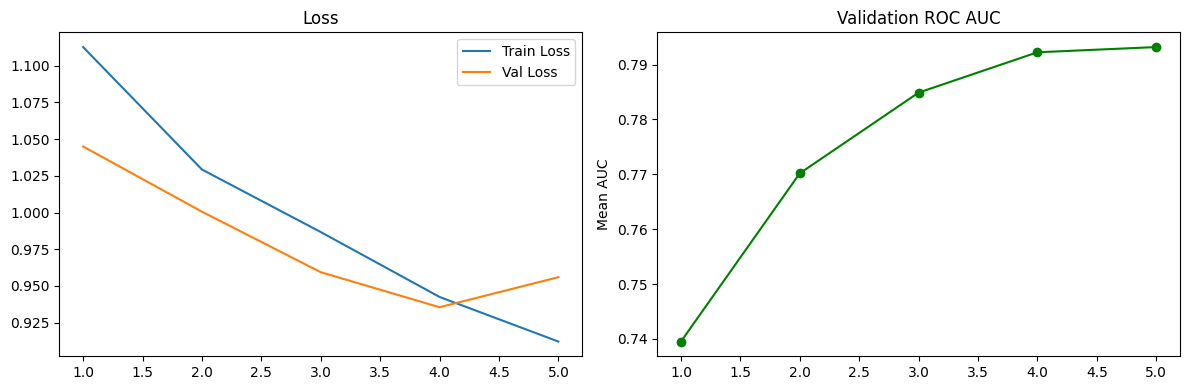

 epoch  train_loss  val_loss  val_auc
     1    1.112794  1.045006 0.739512
     2    1.029318  1.000583 0.770179
     3    0.986686  0.959313 0.784887
     4    0.942432  0.935433 0.792242
     5    0.912033  0.955907 0.793194


In [9]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train Loss')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(hist_df['epoch'], hist_df['val_auc'], marker='o', color='green')
axes[1].set_title('Validation ROC AUC')
axes[1].set_ylabel('Mean AUC')
plt.tight_layout()
plt.show()
print(hist_df.to_string(index=False))

# 7. Inference with TTA
### 7.1 โหลด best model และทำนาย test set

ใช้ Test Time Augmentation (TTA): รัน N passes ด้วย augmentation ต่างกัน แล้ว average ผลลัพธ์
ช่วยเพิ่ม AUC ได้ประมาณ 0.01-0.02

In [10]:
# โหลด best model
model.load_state_dict(torch.load(model_path, map_location=DEVICE))
model.eval()
print(f'Loaded best model (AUC={best_auc:.4f})')

all_filenames = []
all_preds     = []

if USE_TTA:
    print(f'Running TTA with {TTA_N} passes...')
    # สร้าง TTA datasets
    tta_datasets = [
        ChestDataset(test_df, test_img_dir, LABEL_COLUMNS, tta_transform, is_test=True)
        for _ in range(TTA_N)
    ]
    tta_loaders = [
        DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
        for ds in tta_datasets
    ]

    # รัน TTA
    tta_preds_list = []
    for tta_i, loader in enumerate(tta_loaders):
        preds_i   = []
        fnames_i  = []
        with torch.no_grad():
            for imgs, fnames in tqdm(loader, desc=f'TTA {tta_i+1}/{TTA_N}', leave=False):
                imgs = imgs.to(DEVICE)
                logits = model(imgs)
                probs  = torch.sigmoid(logits).cpu().numpy()
                preds_i.append(probs)
                fnames_i.extend(fnames)
        tta_preds_list.append(np.concatenate(preds_i, axis=0))
        if tta_i == 0:
            all_filenames = fnames_i

    # Average TTA predictions
    all_preds = np.mean(tta_preds_list, axis=0)

else:
    print('Running single-pass inference...')
    with torch.no_grad():
        for imgs, fnames in tqdm(test_loader, desc='Inference'):
            imgs  = imgs.to(DEVICE)
            logits= model(imgs)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_preds.append(probs)
            all_filenames.extend(fnames)
    all_preds = np.concatenate(all_preds, axis=0)

print(f'Predictions shape: {all_preds.shape}')
print(f'Filename count   : {len(all_filenames)}')

Loaded best model (AUC=0.7932)
Running TTA with 5 passes...


TTA 1/5:   0%|          | 0/79 [00:00<?, ?it/s]

TTA 2/5:   0%|          | 0/79 [00:00<?, ?it/s]

TTA 3/5:   0%|          | 0/79 [00:00<?, ?it/s]

TTA 4/5:   0%|          | 0/79 [00:00<?, ?it/s]

TTA 5/5:   0%|          | 0/79 [00:00<?, ?it/s]

Predictions shape: (2506, 13)
Filename count   : 2506


# 8. Create Submission File
### 8.1 สร้างไฟล์ submission ตาม format ที่กำหนด

In [11]:
sub_df = pd.DataFrame({'filename': all_filenames})
for i, col in enumerate(LABEL_COLUMNS):
    sub_df[col] = all_preds[:, i]

# ตรวจ format ตาม sample submission
print('Submission shape:', sub_df.shape)
print('Expected shape  :', sample_df.shape)
assert sub_df.shape[0] == sample_df.shape[0], \
    f'Row mismatch! sub={sub_df.shape[0]} vs sample={sample_df.shape[0]}'
assert list(sub_df.columns) == ['filename'] + LABEL_COLUMNS, \
    f'Column mismatch!\n  Got: {list(sub_df.columns)}'

# ตรวจค่า NaN / Inf
assert not sub_df[LABEL_COLUMNS].isnull().any().any(), 'Found NaN in predictions!'
assert not np.isinf(sub_df[LABEL_COLUMNS].values).any(), 'Found Inf in predictions!'
assert (sub_df[LABEL_COLUMNS].values >= 0).all() and (sub_df[LABEL_COLUMNS].values <= 1).all(), \
    'Predictions not in [0, 1]!'

print('\n✅ All sanity checks passed!')
display(sub_df.head())

sub_df.to_csv(submission_path, index=False)
print(f'\nSaved → {submission_path}')

Submission shape: (2506, 14)
Expected shape  : (2506, 14)

✅ All sanity checks passed!


,filename,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax
0,cxr00001.jpg,0.920995,0.695246,0.504272,0.364799,0.659747,0.303192,0.302170,0.510751,0.013408,0.983143,0.170656,0.303686,0.672743
1,cxr00002.jpg,0.819022,0.320460,0.443267,0.064108,0.579680,0.546016,0.409898,0.446916,0.171890,0.794899,0.333056,0.364808,0.561118
2,cxr00003.jpg,0.775373,0.712807,0.462322,0.527432,0.484002,0.579671,0.445888,0.543341,0.075233,0.860748,0.528293,0.377289,0.347086
3,cxr00007.jpg,0.237632,0.717541,0.397604,0.705588,0.514984,0.441728,0.544269,0.594351,0.275217,0.207880,0.752243,0.534598,0.150255
4,cxr00008.jpg,0.233316,0.648409,0.145186,0.437082,0.385178,0.269696,0.312869,0.306660,0.627357,0.062205,0.141081,0.356670,0.011118



Saved → /kaggle/working/5hack_chest_disease_v2_submission.csv


# 9. Summary
### สรุปผลการทดลอง

In [12]:
print('=' * 60)
print('EXPERIMENT SUMMARY')
print('=' * 60)
print(f'Architecture : DenseNet121 (pretrained ImageNet)')
print(f'Image size   : {IMG_SIZE}x{IMG_SIZE}')
print(f'Epochs       : {NUM_EPOCHS}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'LR backbone  : {LR_BACKBONE}')
print(f'LR head      : {LR_HEAD}')
print(f'TTA passes   : {TTA_N if USE_TTA else "None"}')
print(f'Best Val AUC : {best_auc:.4f}')
print(f'Submission   : {submission_path}')
print('=' * 60)

print('\nNext experiments if time permits:')
print('1. EffcientNet-B4 หรือ ResNet50 ensemble กับ DenseNet121')
print('2. เพิ่ม epochs เป็น 10 ถ้ายัง train ได้')
print('3. ขยาย image size เป็น 256 หรือ 320')

EXPERIMENT SUMMARY
Architecture : DenseNet121 (pretrained ImageNet)
Image size   : 224x224
Epochs       : 5
Batch size   : 32
LR backbone  : 0.0001
LR head      : 0.001
TTA passes   : 5
Best Val AUC : 0.7932
Submission   : /kaggle/working/5hack_chest_disease_v2_submission.csv

Next experiments if time permits:
1. EffcientNet-B4 หรือ ResNet50 ensemble กับ DenseNet121
2. เพิ่ม epochs เป็น 10 ถ้ายัง train ได้
3. ขยาย image size เป็น 256 หรือ 320
